# `gwtf` global-fit mode: per-walker data and PSD

This notebook demonstrates the `gf_mode` ("global-fit mode") option of `AnalyticTimeFrequencyWaveform`.

A global fit runs a parallel-tempered sampler: `ntemps` temperature rungs × `nwalkers` walkers, so the
generator is handed `n_sources = nwalkers × ntemps` parameter vectors per call. The data and the PSD,
however, live **per walker** — there are only `nwalkers` of each:

- `channels` has shape `(nwalkers, nT, nF, n_channels)` — walker `w`'s data (e.g. the residual left
  after the other source types have been subtracted).
- `psds` has shape `(nwalkers, nT, nF, n_channels)` — walker `w`'s PSD.

The `data_indices` argument is the map between the two axes: `data_indices[s]` is the walker that
source `s` belongs to, i.e. the index into the leading axis of **both** `channels` and `psds`. The
parameter batch is laid out walker-fastest, so with `nwalkers = 4` and `ntemps = 2` it is simply

```python
data_indices = np.tile(np.arange(nwalkers), ntemps)   # [0, 1, 2, 3, 0, 1, 2, 3]
```

— the second block of four are the same four walkers at the second temperature, and each is scored
against its own walker's data and PSD. Source `s` therefore computes

$$\langle d_{\,\mathrm{data\_indices}[s]} \mid h_s \rangle, \qquad
  \langle h_s \mid h_s \rangle$$

with both inner products weighted by `psds[data_indices[s]]`.

For contrast, in the default (non-`gf`) mode `channels` and `psds` are single `(nT, nF, n_channels)`
arrays shared by every source in the batch, and `data_indices` must be left as `None`.

> **Note:** `gf_mode` only supports the per-segment statistic kernels. `compute_statistic=True` is
> required, and the semi-coherent search path (`N_seg`) is not supported.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from pygwtf.generator import AnalyticTimeFrequencyWaveform
from pygwtf.models import TaylorT2Ecc

## The time-frequency grid

Global-fit mode carries one data array and one PSD per walker, so those arrays cost
`nwalkers × nT × nF × n_channels × 8` bytes each. We therefore use a coarser frequency grid than the
quickstart (`dt = 20 s`, so `f_max = 25 mHz`) to keep this example to a few hundred MB.

In [2]:
# Define the parameters for the time-frequency grid
dT = 86400 / 4  # 6 hours # SFT time.
nT = 365 * 4  # 1 year # Number of SFT time bins in the total observation
dt = 20  # time step for the *time-domain* data -> used to determine fmax for the SFT
dF = 1 / dT  # Frequency spacing within the SFT.
fmax = 1 / (2 * dt)  # Nyquist frequency for the time-domain data

nF = int((fmax) / dF) + 1  # Number of frequency bins needed to cover the Nyquist frequency.

config = {
    "dT": dT,
    "nT": nT,
    "dt": dt,
    "dF": dF,
    "nF": nF,
    "kernel_width": 10,  # Number of frequency bins to use in the fresnel kernel
}

print(f"grid: nT={nT}, nF={nF} -> one (nT, nF, 3) complex array is "
      f"{nT * nF * 3 * 16 / 1e6:.0f} MB")

grid: nT=1460, nF=541 -> one (nT, nF, 3) complex array is 38 MB


## Build the observed data

We build a single time-frequency dataset from two injected sources, using the TDI (AET) channels
(`tdi_type=2`, so `n_channels = 3`). This plays the role of the full data stream; the per-walker
residuals are constructed from it below.

<b>Note: each walker is still dealing with just one source at a time — we are emulating an RJMCMC
step here, where each walker samples a different source.</b>

The two injections are deliberately placed close in frequency (4.0 and 4.2 mHz) so that they
**overlap on the time-frequency grid**. That overlap is what makes this example non-trivial: it means
each walker's imperfect subtraction of the second source leaves a residual *underneath* the templates
being scored, so the `nwalkers` data arrays genuinely differ where it matters. Had the confusion
source sat in a disjoint band, every walker would see identical data under its template and the
source -> walker map would be unobservable.

In [3]:
# Generator used to synthesise the injected TDI data (default, non-gf mode).
# We also re-use it later as an independent reference for the verification checks.
data_generator = AnalyticTimeFrequencyWaveform(
    model_class=TaylorT2Ecc,
    config=config,
    tdi_type=2,
)

# Two injected sources whose superposition forms the data.
injection_pars = {
    "M": np.array([30.0, 42.0]),
    "eta": np.array([0.25, 0.20]),
    "cosi": np.array([0.5, 0.2]),
    "e0": np.array([1e-3, 2e-3]),
    "D": np.array([1e3, 1e3]),
    "f0": np.array([4e-3, 4.2e-3]),
    "phi_coal": np.array([0.1, 0.7]),
}

# Response/extrinsic parameters [cosi, pol, ecliptic_long, ecliptic_lat], one row per source.
injection_response = np.array(
    [
        [injection_pars["cosi"][0], np.pi / 6, 5 * np.pi / 4, np.pi / 3],
        [injection_pars["cosi"][1], np.pi / 5, np.pi, np.pi / 4],
    ]
)

# Per-source waveforms, and their sum -> the (nT, nF, 3) AET data array.
injection_waveforms = data_generator(
    injection_pars, parameters_response=injection_response
)
signal = injection_waveforms.sum(0)

# Flat PSD on the AET channels.
PSD_LEVEL = 1e-34
psd = np.ones_like(signal.real) * PSD_LEVEL

print("data shape:", signal.shape, "| psd shape:", psd.shape)

Spacecraft orbits not supplied. Falling back to analytic orbits
Spacecraft light travel times not supplied. Falling back to analytic calculation
data shape: (1460, 541, 3) | psd shape: (1460, 541, 3)


## Set up the walkers: `nwalkers` data arrays and `nwalkers` PSDs

Each walker in the global fit holds:

1. its **own data array**
2. its **own PSD**

Both arrays therefore have a leading `nwalkers` axis: `(nwalkers, nT, nF, n_channels)`.

In [4]:
nwalkers = 4
rng = np.random.default_rng(1729)

# Each walker has subtracted the confusion source with a different (imperfect) amplitude, so the
# residual data underneath its template differs from walker to walker.
subtraction_fraction = np.linspace(0.7, 1.0, nwalkers)
channels_gf = np.stack(
    [
        signal - frac * injection_waveforms[1]
        for frac in subtraction_fraction
    ]
)

# Each walker's own PSD, from its own current noise parameters.
psd_scaling = rng.uniform(0.9, 1.1, size=nwalkers)
psds_gf = np.stack([psd * s for s in psd_scaling])

print("channels_gf shape:", channels_gf.shape)
print("psds_gf shape:    ", psds_gf.shape)
print("subtraction fractions:", np.round(subtraction_fraction, 3))
print("psd scalings:         ", np.round(psd_scaling, 3))

channels_gf shape: (4, 1460, 541, 3)
psds_gf shape:     (4, 1460, 541, 3)
subtraction fractions: [0.7 0.8 0.9 1. ]
psd scalings:          [0.906 0.934 0.959 1.015]


## The parameter batch: `n_sources = nwalkers × ntemps`

The sampler proposes one parameter vector per (walker, temperature) pair, so the batch handed to the
generator is `ntemps` times larger than the number of walkers. We scatter the proposals around the
first injected source, with the hot chain scattered more widely than the cold one.

`data_indices` is what ties the two axes together: with the walker-fastest layout used here it is
`np.tile(np.arange(nwalkers), ntemps)`, i.e. `[0, 1, 2, 3, 0, 1, 2, 3]` — source 5, say, is walker 1
at the second temperature and is therefore scored against `channels_gf[1]` and `psds_gf[1]`.

In [6]:
ntemps = 2
n_sources = nwalkers * ntemps

# Wider scatter for the hotter chain. One scale per source, walker-fastest.
temp_scatter = np.repeat([1.0, 3.0], nwalkers)

def scatter(centre, width):
    # One proposal per source, scattered about `centre` by `width` x the chain's temperature scale.
    return centre + width * temp_scatter * rng.normal(size=n_sources)

# The scatter is kept tight (the sampler has converged on the injection) so that the walker-level
# differences -- each walker's own residual data and PSD -- are what the curves below separate on.
walker_pars = {
    "M": scatter(30.0, 5e-4),
    "eta": scatter(0.25, 1e-5),
    "cosi": scatter(0.5, 5e-3),
    "e0": scatter(1e-3, 1e-6),
    "D": np.full(n_sources, 1e3),
    "f0": scatter(4e-3, 1e-9),
    "phi_coal": scatter(0.1, 5e-3),
}

# Response parameters, one row per source.
walker_response = np.column_stack(
    [
        walker_pars["cosi"],
        np.full(n_sources, np.pi / 6),
        np.full(n_sources, 5 * np.pi / 4),
        np.full(n_sources, np.pi / 3),
    ]
)

# source -> walker map: [0, 1, ..., nwalkers-1] repeated once per temperature.
data_indices = np.tile(np.arange(nwalkers), ntemps)

print("n_sources:   ", n_sources, "(=", nwalkers, "walkers x", ntemps, "temperatures)")
print("data_indices:", data_indices)

n_sources:    8 (= 4 walkers x 2 temperatures)
data_indices: [0 1 2 3 0 1 2 3]


## Construct the global-fit generator

We pass `gf_mode=True` and hand the per-walker `channels` and `psds` at construction time. The
generator validates that the trailing axes match `(nT, nF, n_channels)`; the leading axis is checked
against `data_indices` at call time.

In [7]:
gf_generator = AnalyticTimeFrequencyWaveform(
    model_class=TaylorT2Ecc,
    config=config,
    tdi_type=2,
    channels=channels_gf,
    psds=psds_gf,
    gf_mode=True,
)

Spacecraft orbits not supplied. Falling back to analytic orbits
Spacecraft light travel times not supplied. Falling back to analytic calculation


The returned statistic array has shape `(n_sources, nT, 2)` — one row per *source*, not per walker —
where the last axis holds $\langle d \mid h \rangle$ and $\langle h \mid h \rangle$ for each time
segment.

In [8]:
stat_gf = gf_generator(
    walker_pars,
    parameters_response=walker_response,
    compute_statistic=True,  # return per-segment <d|h>, <h|h> rather than the waveform
    data_indices=data_indices,  # source -> walker
)

print("per-source statistic shape:", stat_gf.shape)  # (n_sources, nT, 2)

per-source statistic shape: (8, 1460, 2)


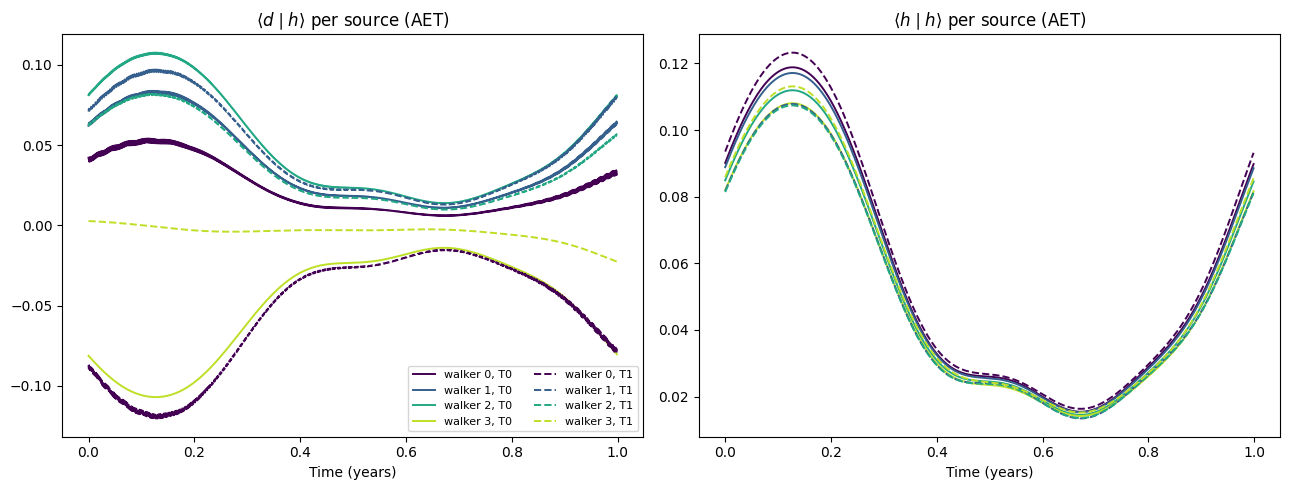

In [10]:
years = gf_generator.t_tranche / (365.25 * 24 * 3600)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
colours = plt.cm.viridis(np.linspace(0, 0.9, nwalkers))
for s in range(n_sources):
    w = data_indices[s]
    temp = s // nwalkers
    style = dict(color=colours[w], ls="-" if temp == 0 else "--", lw=1.4)
    label = f"walker {w}, T{temp}"
    axes[0].plot(years, np.real(stat_gf[s, :, 0]), label=label, **style)
    axes[1].plot(years, np.real(stat_gf[s, :, 1]), label=label, **style)
axes[0].set_title(r"$\langle d \mid h \rangle$ per source (AET)")
axes[1].set_title(r"$\langle h \mid h \rangle$ per source (AET)")
for ax in axes:
    ax.set_xlabel("Time (years)")
axes[0].legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

A single scalar summary per source (e.g. for a likelihood) is obtained by summing the per-segment
inner products over time. The coherent, whole-observation matched-filter SNR of source `s` is
$\langle d\mid h\rangle / \sqrt{\langle h\mid h\rangle}$, summed over segments (you can follow the
same idea to compute the likelihood, appropriately combining the two quantities):

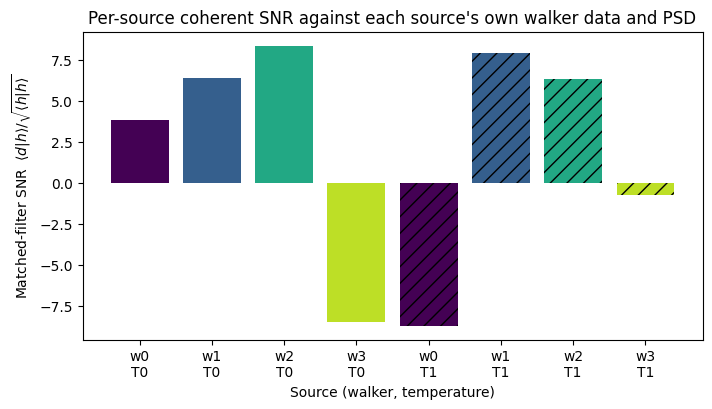

In [11]:
d_h = stat_gf[:, :, 0].sum(axis=1)  # sum over time segments -> (n_sources,)
h_h = stat_gf[:, :, 1].sum(axis=1)

snr = np.real(d_h) / np.sqrt(np.real(h_h))

plt.figure(figsize=(8, 4))
plt.bar(
    np.arange(n_sources),
    snr,
    color=[colours[w] for w in data_indices],
    hatch=["" if s < nwalkers else "//" for s in range(n_sources)],
)
plt.xticks(
    np.arange(n_sources),
    [f"w{data_indices[s]}\nT{s // nwalkers}" for s in range(n_sources)],
)
plt.xlabel("Source (walker, temperature)")
plt.ylabel(r"Matched-filter SNR  $\langle d|h\rangle/\sqrt{\langle h|h\rangle}$")
plt.title("Per-source coherent SNR against each source's own walker data and PSD")
plt.show()

## Passing per-walker data at call time

The per-walker `channels`/`psds` can also be supplied at call time. The shapes are the same:
`(nwalkers, nT, nF, n_channels)`.

In [13]:
stat_gf_calltime = gf_generator(
    walker_pars,
    parameters_response=walker_response,
    channels=channels_gf,  # (nwalkers, nT, nF, n_channels)
    psds=psds_gf,
    compute_statistic=True,
    data_indices=data_indices,
)

# Identical to using the stored arrays, since we passed the same data.
print("matches stored-array result:", np.allclose(stat_gf_calltime, stat_gf))

matches stored-array result: True


## Consistency check against the shared-data path

Global-fit mode is only a bookkeeping device: the sources mapped to walker `w` must reproduce exactly
what the ordinary shared-data path computes for those same parameters against the single data array
`channels_gf[w]` and PSD `psds_gf[w]`. We check that walker by walker.

In [14]:
for w in range(nwalkers):
    sources = np.flatnonzero(data_indices == w)  # both temperature rungs of this walker
    sub_pars = {key: value[sources] for key, value in walker_pars.items()}

    stat_shared = data_generator(
        sub_pars,
        parameters_response=walker_response[sources],
        channels=channels_gf[w],  # shared (nT, nF, n_channels)
        psds=psds_gf[w],
        compute_statistic=True,
    )

    print(
        f"walker {w}: sources {sources} -> max abs difference "
        f"{np.max(np.abs(stat_gf[sources] - stat_shared)):.3e}, "
        f"match: {np.allclose(stat_gf[sources], stat_shared)}"
    )

walker 0: sources [0 4] -> max abs difference 0.000e+00, match: True
walker 1: sources [1 5] -> max abs difference 0.000e+00, match: True
walker 2: sources [2 6] -> max abs difference 0.000e+00, match: True
walker 3: sources [3 7] -> max abs difference 0.000e+00, match: True


Finally, a check that the map is actually doing something: rotating `data_indices` scores every
source against the *wrong* walker's data and PSD, which must change the answer.

In [15]:
stat_mismapped = gf_generator(
    walker_pars,
    parameters_response=walker_response,
    compute_statistic=True,
    data_indices=np.roll(data_indices, 1),
)

print("mis-mapped result differs:", not np.allclose(stat_mismapped, stat_gf))

mis-mapped result differs: True
